# Exploratory Data Analysis of Student Learning Behavior for Clustering and Profiling

## Introduction

This notebook focuses on exploratory data analysis (EDA) of student learning behavior. The goal is to understand data quality, feature distributions, outliers, and relationships between variables before any clustering model is trained.

The outputs of this notebook are a clean, well-documented dataset and a finalized modeling matrix that will be used later in a separate modeling notebook. In that modeling stage, clustering methods such as K-Means and DBSCAN will be applied and compared.

Through this EDA process, we identify meaningful behavior patterns, reduce noise, and prepare features that support more reliable student profiling and personalized learning strategies.

## 1. Environment Setup
Importing the necessary libraries and initial configuration.

In [64]:
# Import required libraries
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

# Notebook display and plot configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Project paths
DATA_PATH = Path('../data/merged_dataset.csv')

## 2. Data Loading and Preprocessing

This section includes:
- Initialization and Data Import
- Harmonizing columns
- Handling missing values
- Standardization, Conversion of Data Types, and Harmonizing Formats
- Aligning keys for merging
- Detecting and handling duplicates
- Merging datasets
- Normalization and standardization

In [65]:
# 1. LOAD THE DATASET
df = pd.read_csv(DATA_PATH)
df.head()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [13]:
# 2. SHAPE — How many rows and columns?
print(df.shape)

(14003, 16)


In [14]:
# 3. COLUMN NAMES — What features do we have?
print(df.columns.tolist())

['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']


In [15]:
# 4. DATA TYPES — Are columns the right type?
display(df.dtypes)

# Quick summary: how many of each type?
print(df.dtypes.value_counts())

# Watch out: numeric columns stored as 'object' (string)
obj_num = [c for c in df.select_dtypes(include='object').columns if pd.to_numeric(df[c], errors='coerce').notna().any()]
print(obj_num if obj_num else 'None')

StudyHours              int64
Attendance              int64
Resources               int64
Extracurricular         int64
Motivation              int64
Internet                int64
Gender                  int64
Age                     int64
LearningStyle           int64
OnlineCourses           int64
Discussions             int64
AssignmentCompletion    int64
ExamScore               int64
EduTech                 int64
StressLevel             int64
FinalGrade              int64
dtype: object

int64    16
Name: count, dtype: int64
None


In [16]:
# Head, Tail, and a Random Sample
display(df.head())
display(df.tail())
display(df.sample(5, random_state=42))

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
13998,30,62,0,1,1,1,0,22,2,2,1,100,71,1,2,1
13999,30,62,0,1,1,1,0,23,3,12,1,72,55,1,1,2
14000,22,90,2,0,1,1,0,23,3,0,1,80,56,0,0,2
14001,22,90,2,0,1,1,0,29,2,16,0,50,62,1,2,2
14002,10,86,2,1,2,1,0,18,2,8,1,66,77,1,2,1


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
2144,10,64,0,0,0,1,0,23,2,13,1,67,59,0,1,2
4125,14,85,0,1,1,1,1,19,1,4,1,58,56,1,0,2
2140,10,64,2,0,2,1,0,23,2,13,1,67,59,0,1,2
5391,22,76,1,1,2,1,1,19,3,18,0,91,85,0,2,0
11912,20,75,1,1,0,1,0,22,2,9,1,88,99,0,0,0


In [17]:
# MISSING VALUES — Where is data absent?
missing = df.isna().sum()
display(missing[missing > 0])

Series([], dtype: int64)

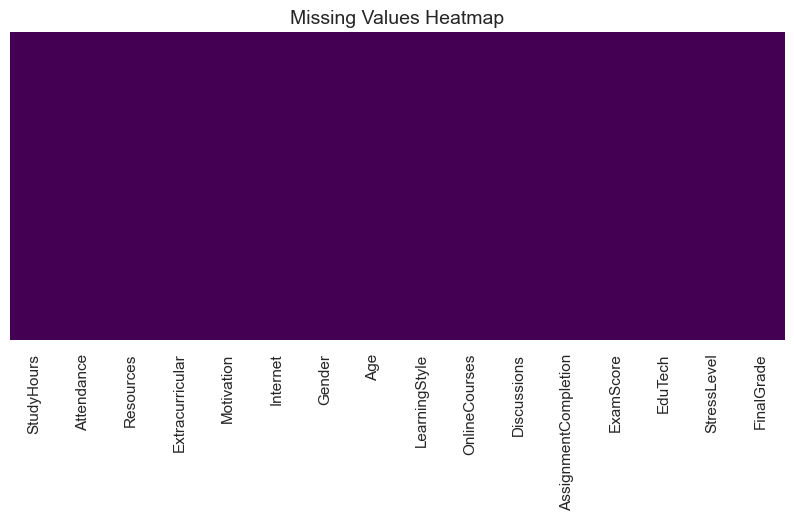

In [18]:
# Visualize missing values as a heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [19]:
# Overall missing percentage
missing_pct = df.isna().mean().mean() * 100
print(f"Overall missing percentage: {missing_pct:.2f}%")

Overall missing percentage: 0.00%


In [20]:
# DUPLICATE ROWS — Are there exact copies?
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

Duplicate rows: 1534


In [21]:
# PHASE 1 SUMMARY REPORT
print('PHASE 1 SUMMARY REPORT')
print(f"Rows, Columns: {df.shape}")
print(f"Total Missing Values: {int(df.isna().sum().sum())}")
print(f"Overall Missing %: {df.isna().mean().mean() * 100:.2f}%")
print(f"Duplicate Rows: {int(df.duplicated().sum())}")

PHASE 1 SUMMARY REPORT
Rows, Columns: (14003, 16)
Total Missing Values: 0
Overall Missing %: 0.00%
Duplicate Rows: 1534


In [66]:
# 1. CLASSIFY COLUMNS BY TYPE
numeric_cols = df.select_dtypes(include='number').columns.tolist()
binary_cols = [c for c in df.columns if df[c].nunique(dropna=True) == 2]
ordinal_discrete_cols = [c for c in numeric_cols if df[c].nunique(dropna=True) <= 10 and c not in binary_cols]
continuous_numeric_cols = [c for c in numeric_cols if c not in ordinal_discrete_cols and c not in binary_cols]
categorical_cols = [c for c in df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist() if c not in binary_cols]

print('Numeric:', numeric_cols)
print('Continuous numeric:', continuous_numeric_cols)
print('Ordinal/discrete:', ordinal_discrete_cols)
print('Categorical:', categorical_cols)
print('Binary:', binary_cols)

Numeric: ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']
Continuous numeric: ['StudyHours', 'Attendance', 'Age', 'OnlineCourses', 'AssignmentCompletion', 'ExamScore']
Ordinal/discrete: ['Resources', 'Motivation', 'LearningStyle', 'StressLevel', 'FinalGrade']
Categorical: []
Binary: ['Extracurricular', 'Internet', 'Gender', 'Discussions', 'EduTech']


In [23]:
# DESCRIPTIVE STATISTICS — Numeric Features
if continuous_numeric_cols:
    display(df[continuous_numeric_cols].describe().T)
else:
    print('No continuous numeric features found.')

,count,mean,std,min,25%,50%,75%,max
StudyHours,14003.0,19.987431,5.890637,5.0,16.0,20.0,24.0,44.0
Attendance,14003.0,80.194316,11.472181,60.0,70.0,80.0,90.0,100.0
Age,14003.0,23.532172,3.514293,18.0,20.0,24.0,27.0,29.0
OnlineCourses,14003.0,9.891952,6.112801,0.0,5.0,10.0,15.0,20.0
AssignmentCompletion,14003.0,74.502535,14.632177,50.0,62.0,74.0,87.0,100.0
ExamScore,14003.0,70.346926,17.688113,40.0,55.0,70.0,86.0,100.0


In [24]:
# DESCRIPTIVE STATISTICS — Ordinal / Discrete Features
if ordinal_discrete_cols:
    display(df[ordinal_discrete_cols].describe().T)
else:
    print('No ordinal/discrete features found.')

,count,mean,std,min,25%,50%,75%,max
Resources,14003.0,1.104406,0.697362,0.0,1.0,1.0,2.0,2.0
Motivation,14003.0,0.905806,0.695896,0.0,0.0,1.0,1.0,2.0
LearningStyle,14003.0,1.515461,1.112941,0.0,1.0,2.0,3.0,3.0
StressLevel,14003.0,1.304363,0.785383,0.0,1.0,2.0,2.0,2.0
FinalGrade,14003.0,1.447904,1.121550,0.0,0.0,1.0,2.0,3.0


In [25]:
# VALUE COUNTS — Categorical Features
if categorical_cols:
    for col in categorical_cols:
        print(f'\n{col}')
        print(df[col].value_counts(dropna=False))
else:
    print('No categorical features found.')

No categorical features found.


In [33]:
# VALUE COUNTS — Binary Features
if binary_cols:
    for col in binary_cols:
        print(f'\n{col}')
        vc = df[col].value_counts(dropna=False)
        vc.index.name = None
        print(vc.to_string())
else:
    print('No binary features found.')


Extracurricular
1    8320
0    5683

Internet
1    12960
0     1043

Gender
1    7729
0    6274

Discussions
1    8484
0    5519

EduTech
1    9929
0    4074


In [28]:
# UNIQUE VALUE COUNTS — Full Overview
unique_counts = df.nunique(dropna=False).sort_values(ascending=False)
display(unique_counts)

ExamScore               61
AssignmentCompletion    51
Attendance              41
StudyHours              37
OnlineCourses           21
Age                     12
LearningStyle            4
FinalGrade               4
Resources                3
Motivation               3
StressLevel              3
Extracurricular          2
Internet                 2
Gender                   2
Discussions              2
EduTech                  2
dtype: int64

In [29]:
# Visualize — Bar charts for all categorical columns
if categorical_cols:
    for col in categorical_cols:
        plt.figure(figsize=(8, 4))
        df[col].value_counts(dropna=False).plot(kind='bar')
        plt.title(f'Bar Chart: {col}')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print('No categorical columns to plot.')

No categorical columns to plot.


In [30]:
# Categorical bar charts
if categorical_cols:
    top_n = min(6, len(categorical_cols))
    plt.figure(figsize=(10, 4 * top_n))
    for i, col in enumerate(categorical_cols[:top_n], 1):
        plt.subplot(top_n, 1, i)
        df[col].value_counts(dropna=False).head(10).plot(kind='bar')
        plt.title(col)
        plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('No categorical columns to plot.')

No categorical columns to plot.


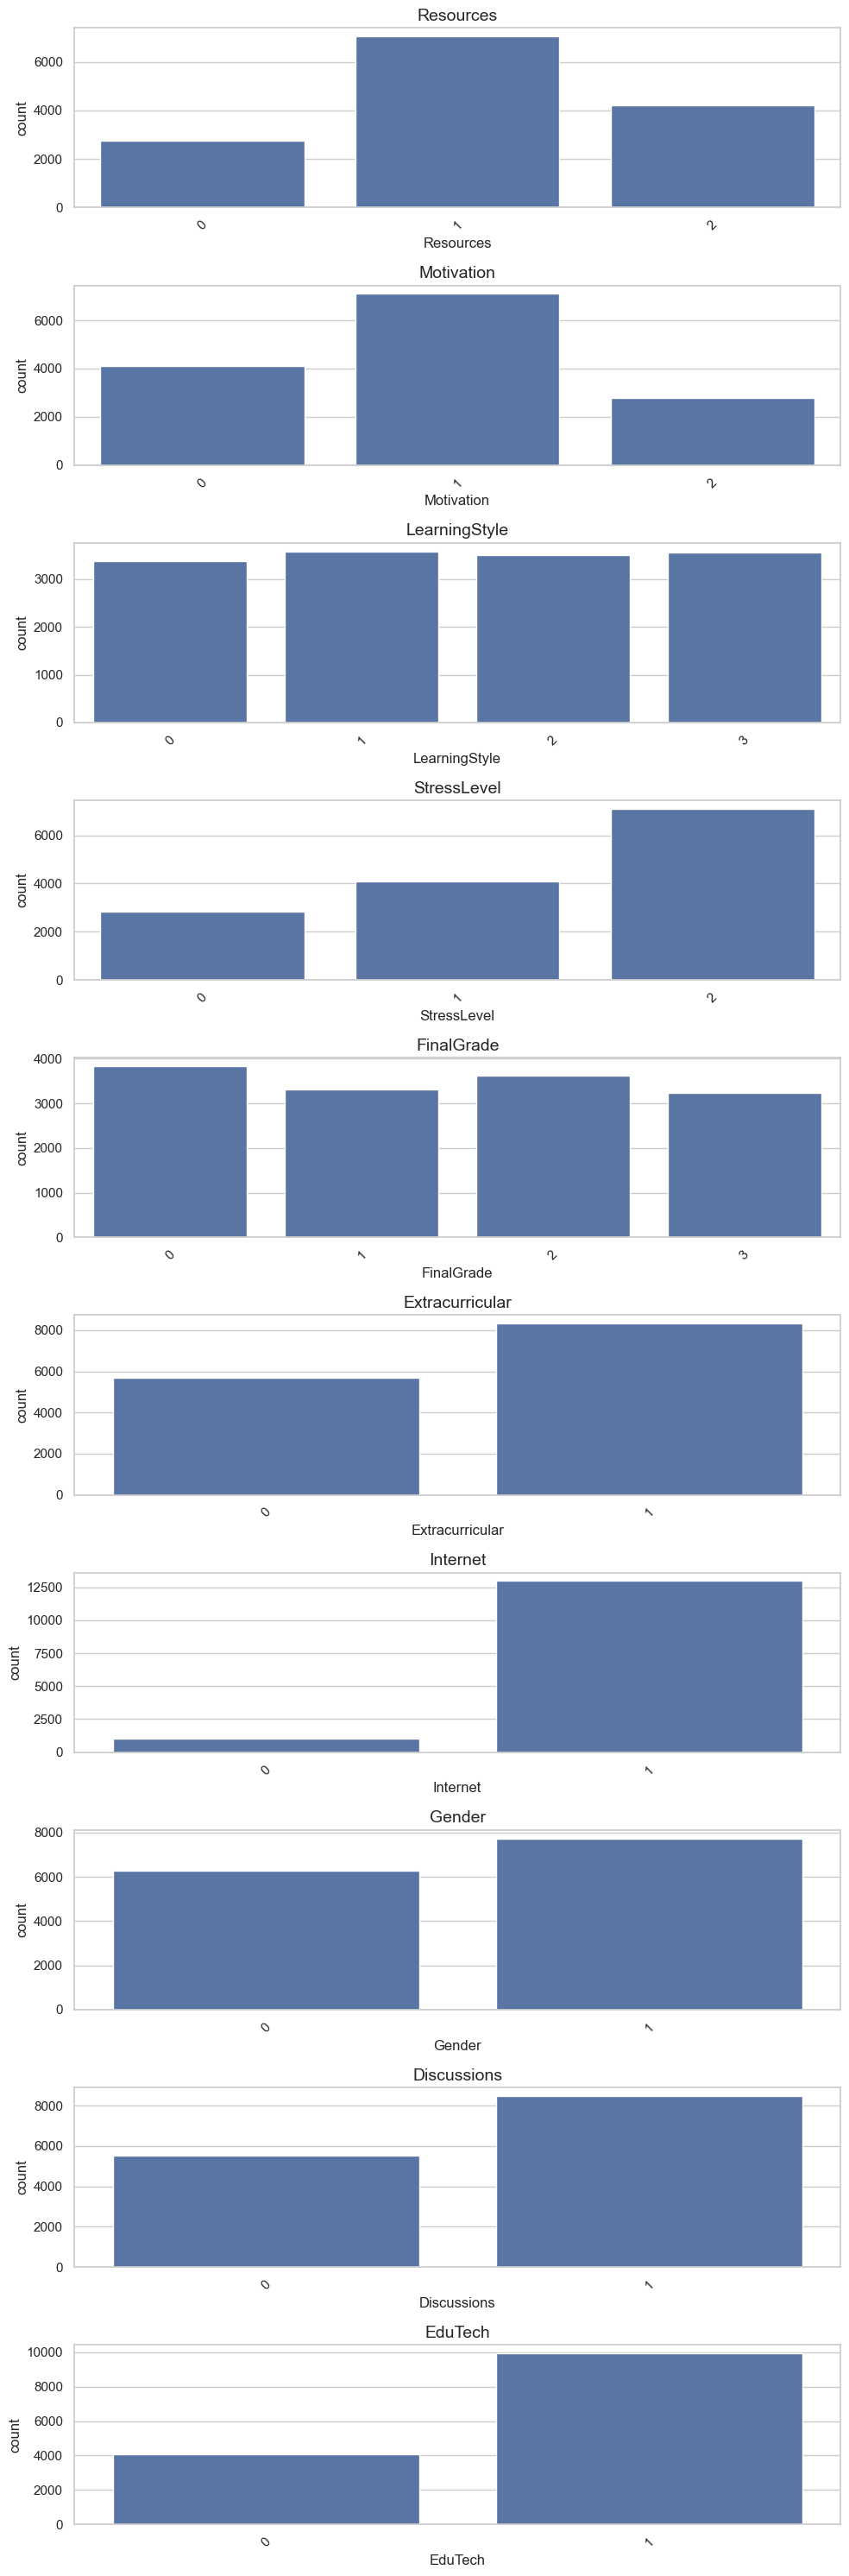

In [31]:
# Ordinal / binary count plots
plot_cols = ordinal_discrete_cols + [c for c in binary_cols if c not in ordinal_discrete_cols]
if plot_cols:
    n = len(plot_cols)
    fig, axes = plt.subplots(n, 1, figsize=(10, 3 * n))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        sns.countplot(data=df, x=col, ax=ax)
        ax.set_title(col)
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No ordinal/binary columns to plot.')

Low → 0
Medium → 1
High → 2

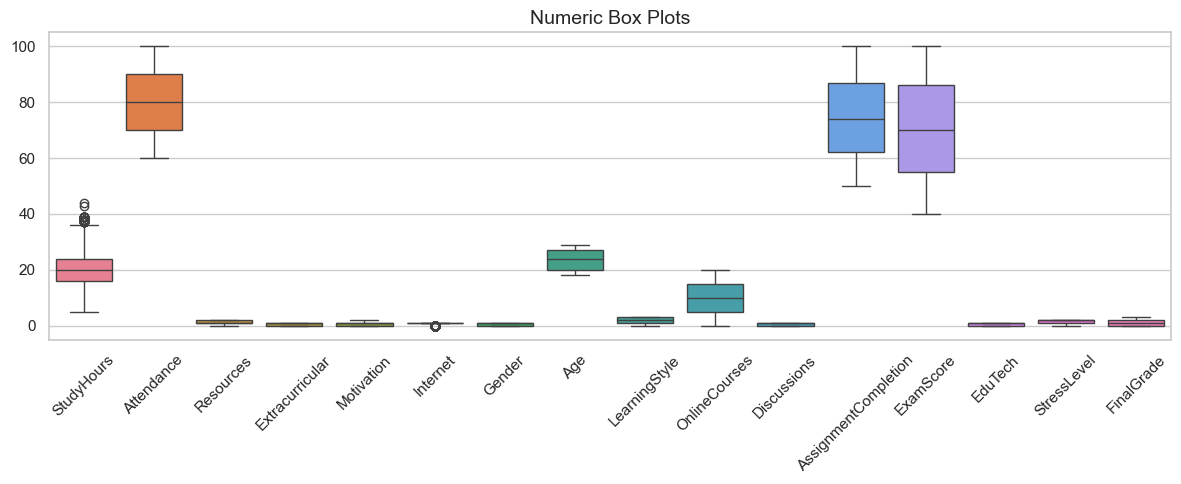

In [32]:
# Numeric box plots
if numeric_cols:
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=df[numeric_cols])
    plt.title('Numeric Box Plots')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No numeric columns to plot.')

## Distribution and Outlier Analysis
Minimal checks for shape, tails, and outlier flags.

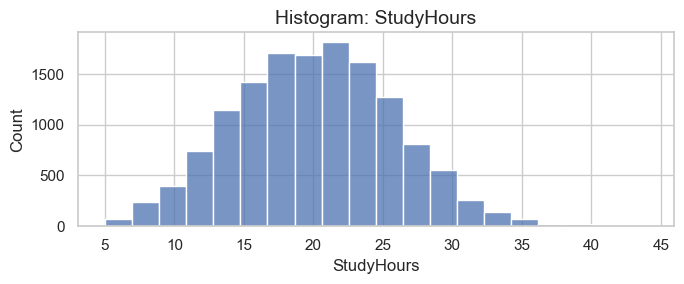

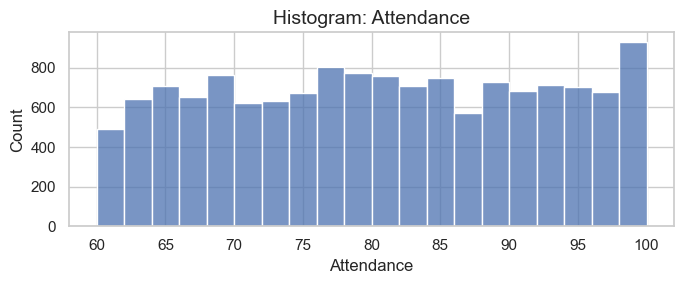

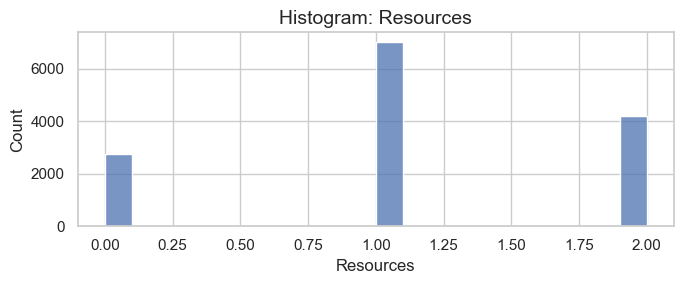

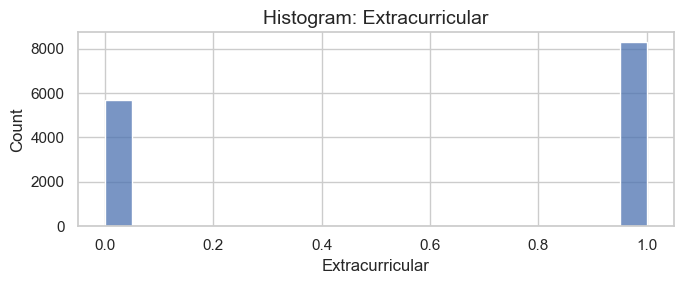

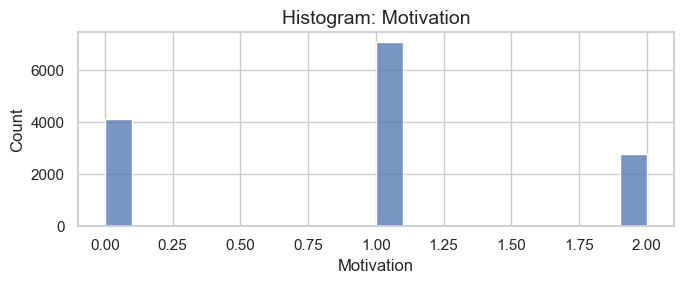

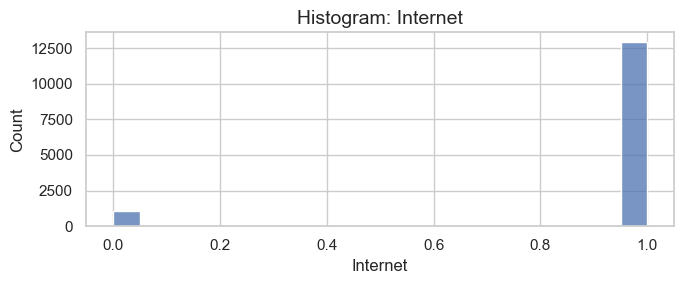

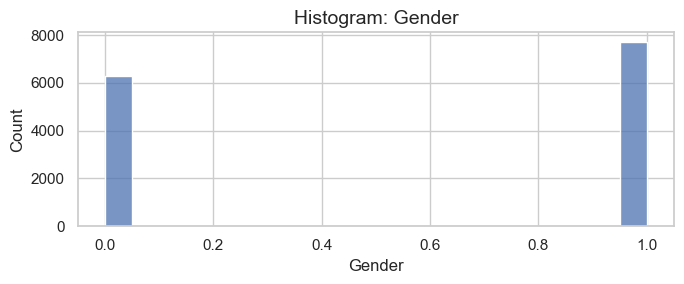

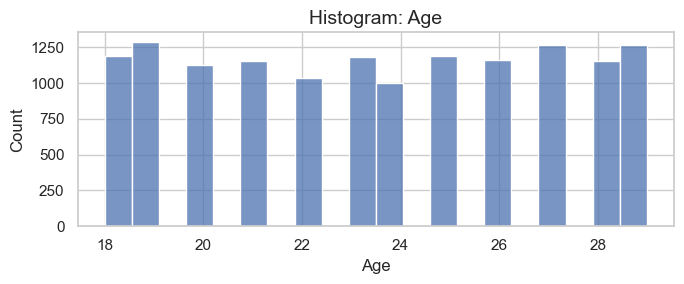

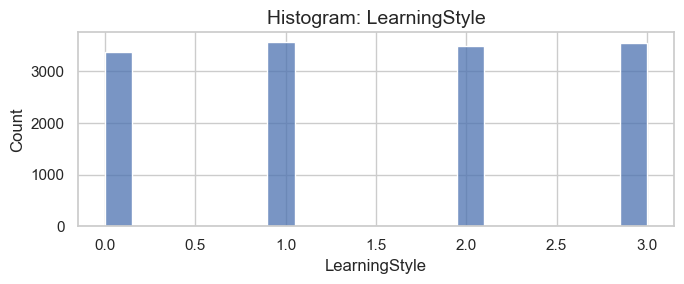

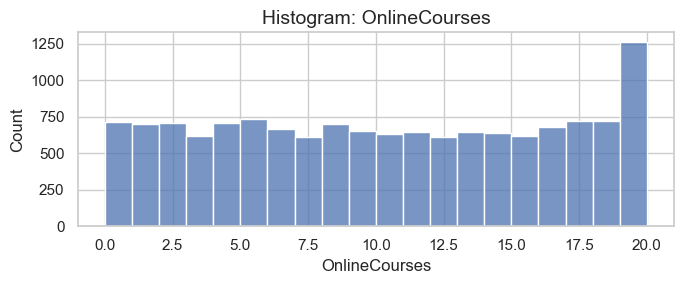

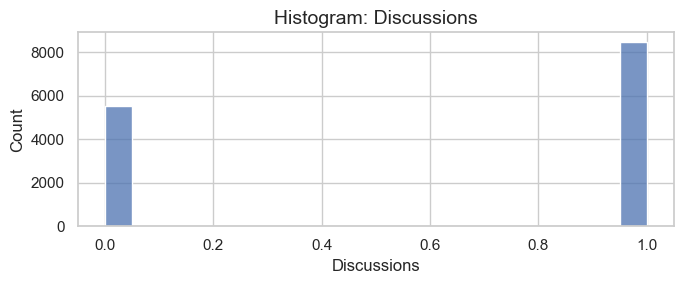

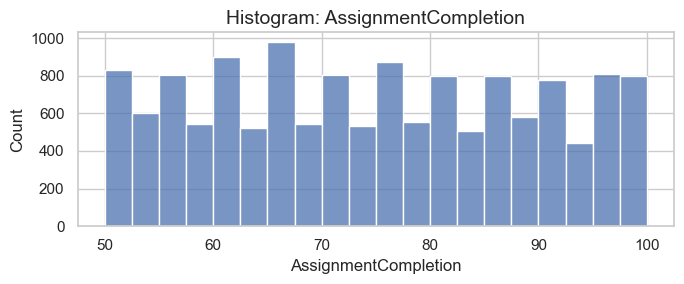

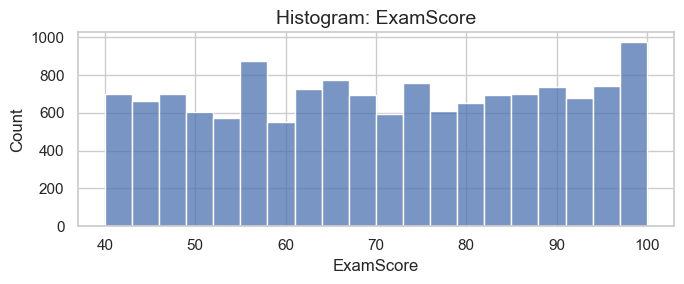

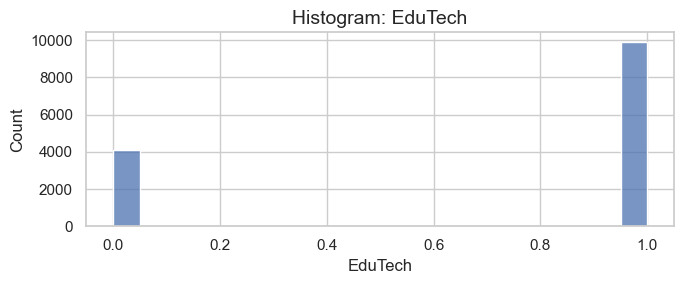

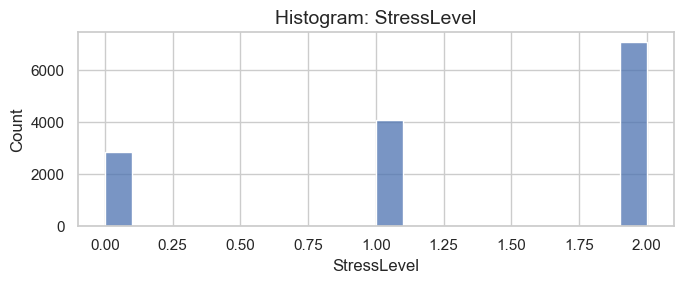

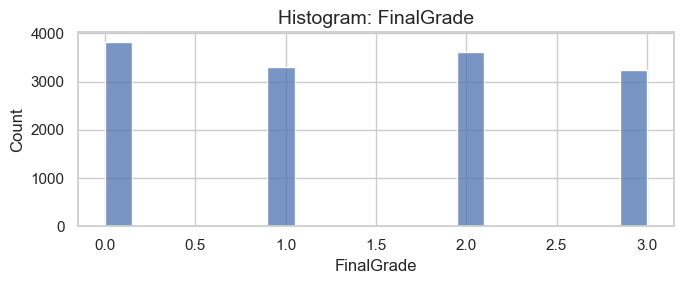

In [42]:
# 1. HISTOGRAM + KDE — One plot per numeric feature
for col in numeric_cols:
    plt.figure(figsize=(7, 3))
    sns.histplot(df[col], bins=20)
    plt.title(f'Histogram: {col}')
    plt.tight_layout()
    plt.show()

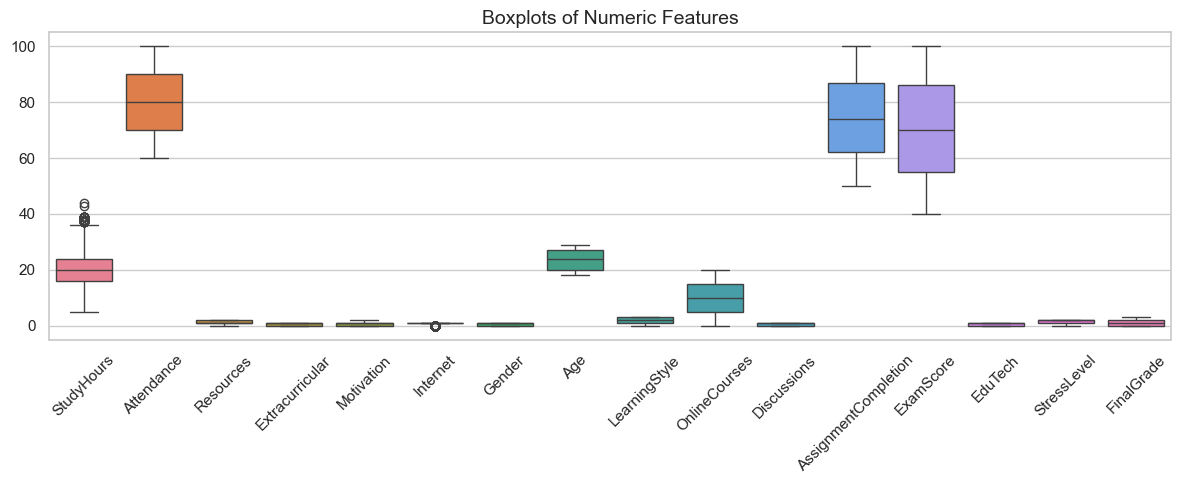

In [35]:
# 2. BOXPLOTS — Side-by-side to compare spread & outliers
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[numeric_cols])
plt.title('Boxplots of Numeric Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# 3. SKEWNESS & KURTOSIS TABLE
skew_kurt = pd.DataFrame({
    'skewness': df[numeric_cols].skew(),
    'kurtosis': df[numeric_cols].kurt()
})
skew_kurt['skew_flag'] = skew_kurt['skewness'].apply(lambda x: 'check' if x > 1 or x < -1 else 'ok')
skew_kurt['kurtosis_flag'] = skew_kurt['kurtosis'].apply(lambda x: 'heavy_tail' if x > 3 else 'ok')
display(skew_kurt.sort_values('skewness', key=lambda s: s.abs(), ascending=False))

,skewness,kurtosis,skew_flag,kurtosis_flag
Internet,-3.241670,8.509640,check,heavy_tail
EduTech,-0.920683,-1.152507,ok,ok
StressLevel,-0.592578,-1.140359,ok,ok
Discussions,-0.433352,-1.812465,ok,ok
Extracurricular,-0.383536,-1.853165,ok,ok
Gender,-0.208966,-1.956613,ok,ok
Resources,-0.144644,-0.945762,ok,ok
Motivation,0.129042,-0.937370,ok,ok
StudyHours,0.098077,-0.197166,ok,ok
AssignmentCompletion,0.049256,-1.181467,ok,ok


In [37]:
# 4. IQR OUTLIER DETECTION
q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)
iqr = q3 - q1
iqr_flags = (df[numeric_cols] < (q1 - 1.5 * iqr)) | (df[numeric_cols] > (q3 + 1.5 * iqr))
iqr_outlier_counts = iqr_flags.sum().sort_values(ascending=False)
display(iqr_outlier_counts)

Internet                1043
StudyHours                45
Attendance                 0
Resources                  0
Extracurricular            0
Motivation                 0
Gender                     0
Age                        0
LearningStyle              0
OnlineCourses              0
Discussions                0
AssignmentCompletion       0
ExamScore                  0
EduTech                    0
StressLevel                0
FinalGrade                 0
dtype: int64

In [38]:
# 5. Z-SCORE OUTLIER DETECTION
z_scores = (df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std(ddof=0)
z_flags = z_scores.abs() > 3
z_outlier_counts = z_flags.sum().sort_values(ascending=False)
display(z_outlier_counts)

Internet                1043
StudyHours                38
Attendance                 0
Resources                  0
Extracurricular            0
Motivation                 0
Gender                     0
Age                        0
LearningStyle              0
OnlineCourses              0
Discussions                0
AssignmentCompletion       0
ExamScore                  0
EduTech                    0
StressLevel                0
FinalGrade                 0
dtype: int64

In [39]:
# 6. OUTLIER ROWS — Which students are outliers?
outlier_rows = df[iqr_flags.any(axis=1)].copy()
print(f'Outlier rows flagged by IQR: {len(outlier_rows)}')
display(outlier_rows.head())

Outlier rows flagged by IQR: 1087


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
33,24,98,0,0,0,0,1,29,0,3,0,65,46,1,2,3
34,24,98,0,0,0,0,1,27,0,0,1,71,83,1,0,1
35,24,98,0,0,0,0,1,25,1,5,1,61,95,1,0,0
75,17,80,2,0,1,0,1,18,1,13,1,68,73,0,2,1
76,17,80,2,0,1,0,1,24,3,11,1,64,69,1,0,2


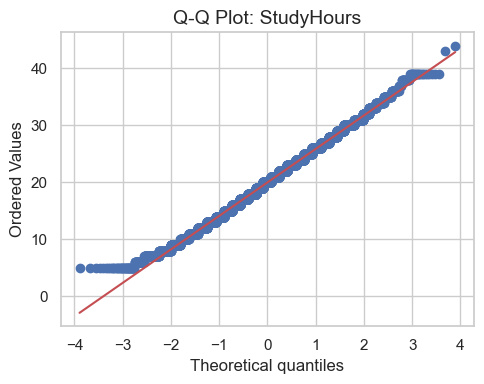

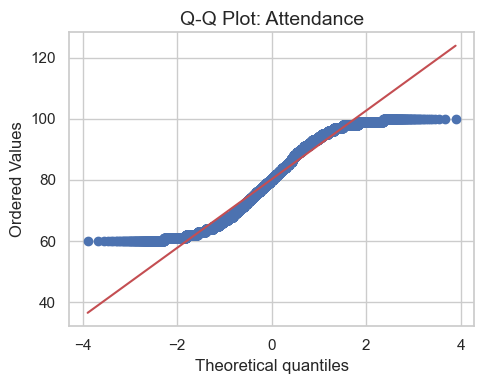

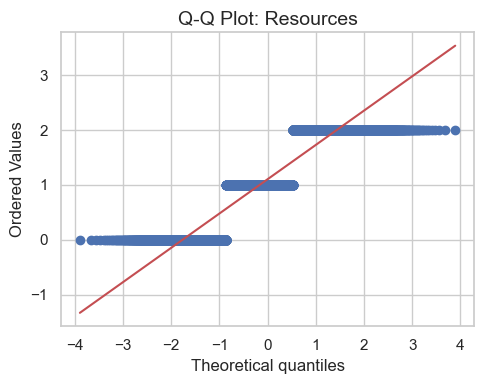

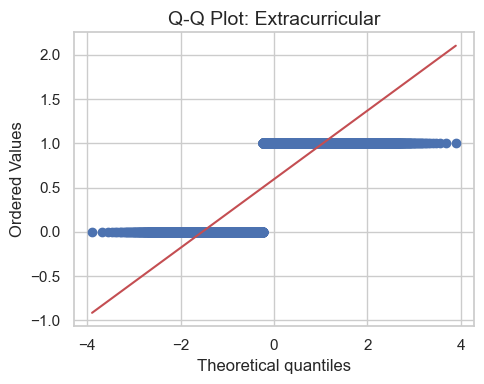

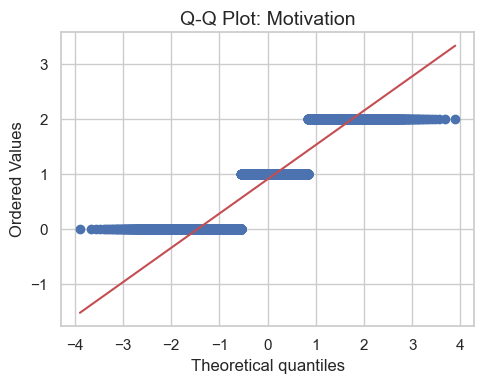

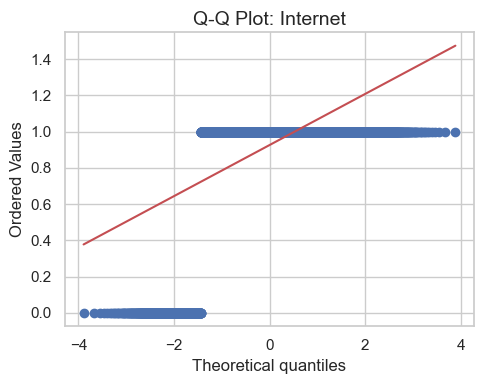

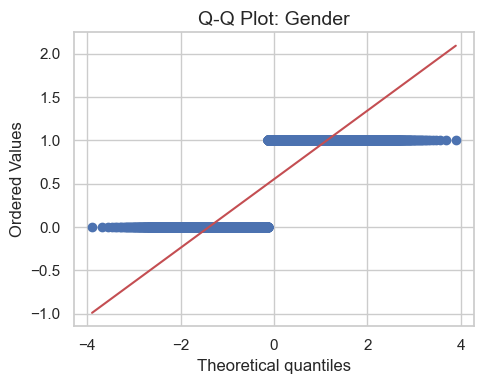

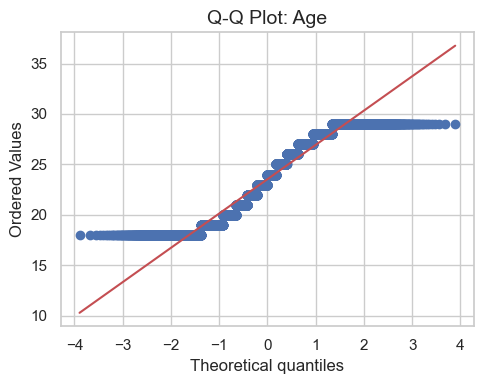

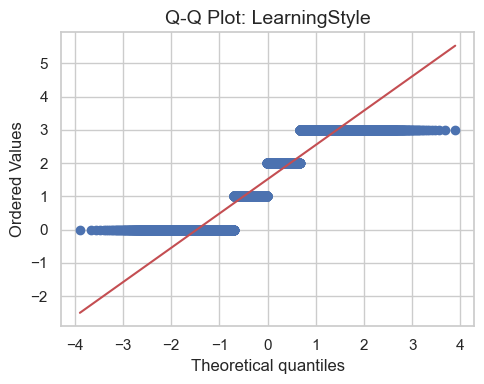

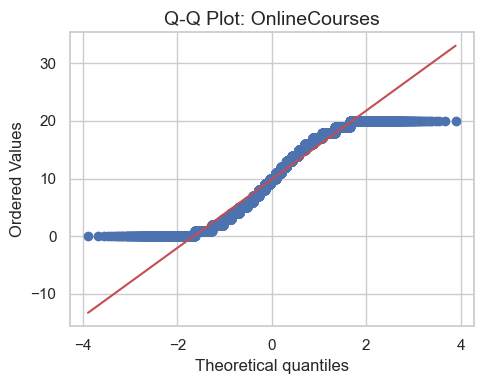

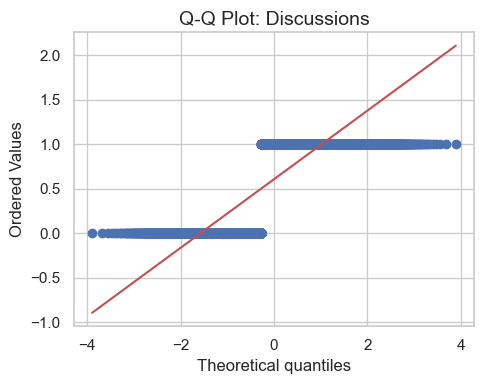

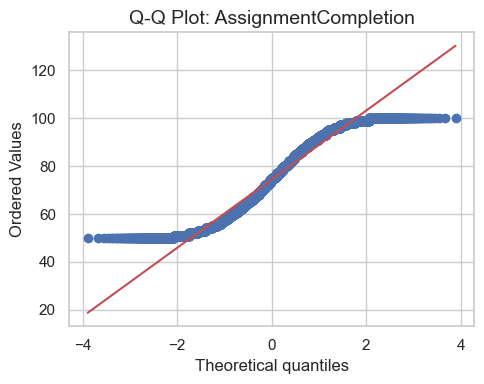

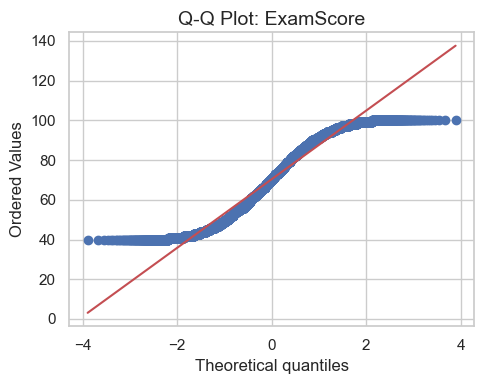

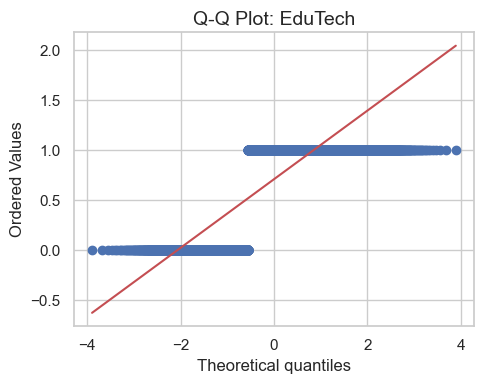

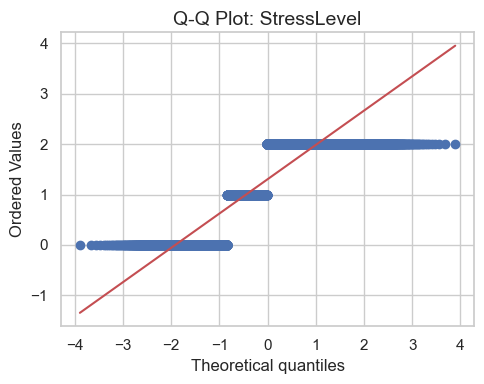

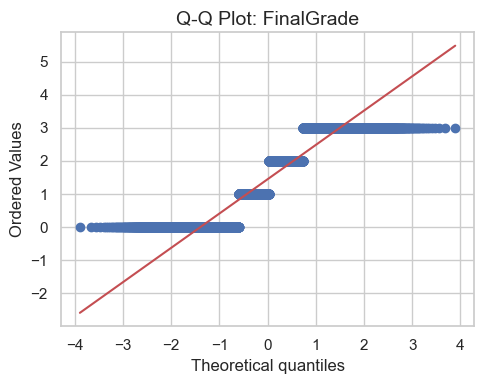

In [40]:
# 7. Q-Q PLOTS — Do numeric features follow a normal dist?
try:
    from scipy import stats
    for col in numeric_cols:
        plt.figure(figsize=(5, 4))
        stats.probplot(df[col].dropna(), dist='norm', plot=plt)
        plt.title(f'Q-Q Plot: {col}')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f'Q-Q plots skipped: {e}')

In [41]:
# DISTRIBUTION SUMMARY TABLE — All columns at a glance
distribution_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unique': df.nunique(dropna=False),
    'missing_pct': (df.isna().mean() * 100).round(2)
})
distribution_summary['is_numeric'] = distribution_summary.index.isin(numeric_cols)
distribution_summary['iqr_outliers'] = distribution_summary.index.map(lambda c: int(iqr_outlier_counts.get(c, 0)))
distribution_summary['zscore_outliers'] = distribution_summary.index.map(lambda c: int(z_outlier_counts.get(c, 0)))
display(distribution_summary)

,dtype,n_unique,missing_pct,is_numeric,iqr_outliers,zscore_outliers
StudyHours,int64,37,0.0,True,45,38
Attendance,int64,41,0.0,True,0,0
Resources,int64,3,0.0,True,0,0
Extracurricular,int64,2,0.0,True,0,0
Motivation,int64,3,0.0,True,0,0
Internet,int64,2,0.0,True,1043,1043
Gender,int64,2,0.0,True,0,0
Age,int64,12,0.0,True,0,0
LearningStyle,int64,4,0.0,True,0,0
OnlineCourses,int64,21,0.0,True,0,0


## Correlations & Relationships
Pearson, Spearman, Cramér's V, and point-biserial checks.

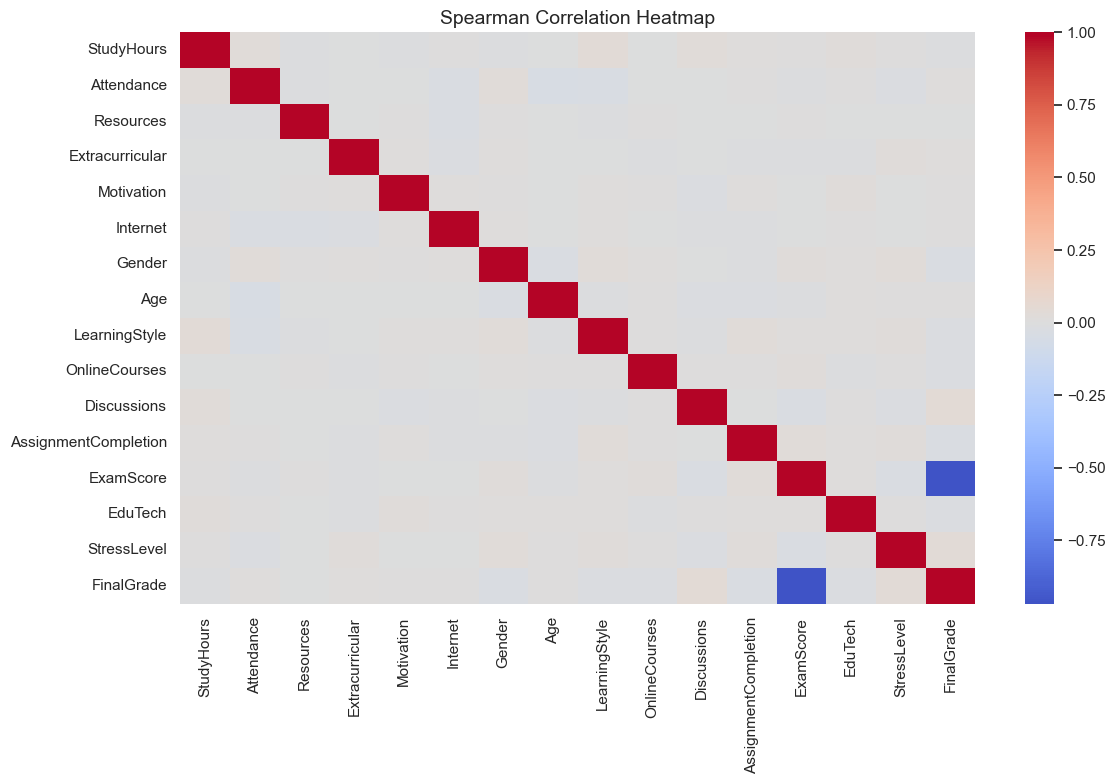

In [46]:
# 1. PEARSON / SPEARMAN CORRELATION HEATMAP
corr = df[numeric_cols].corr(method='spearman')
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Spearman Correlation Heatmap')
plt.tight_layout()
plt.show()

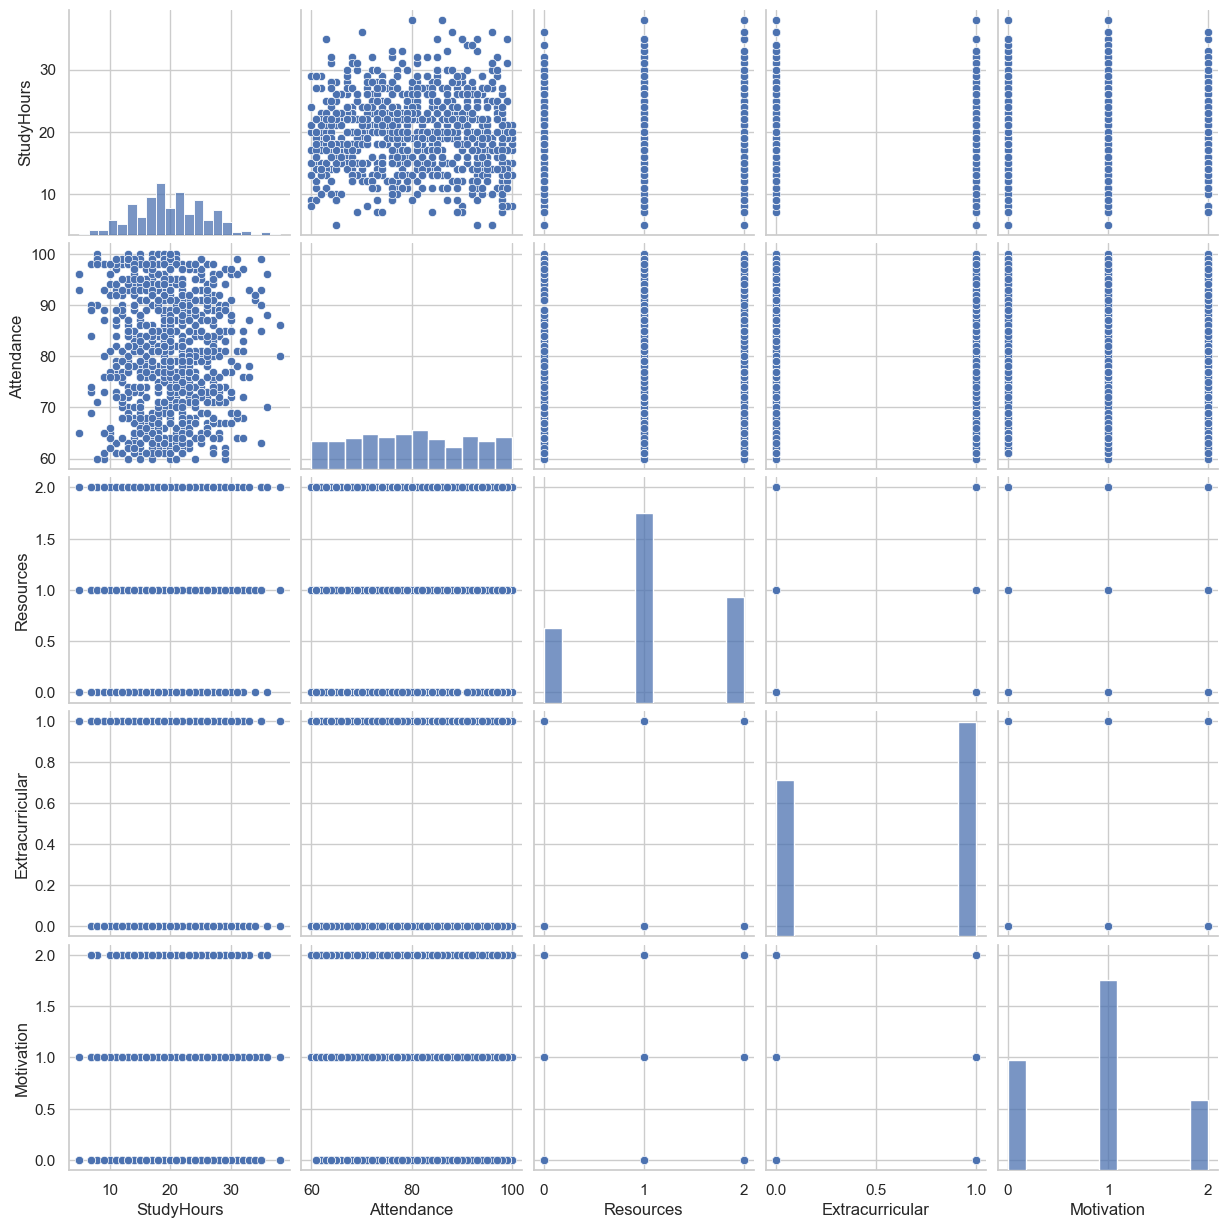

In [47]:
# 2. PAIRPLOT ON KEY NUMERIC FEATURES
pair_cols = numeric_cols[:5]
pair_data = df[pair_cols].sample(n=min(len(df), 1000), random_state=42)
sns.pairplot(pair_data)
plt.show()

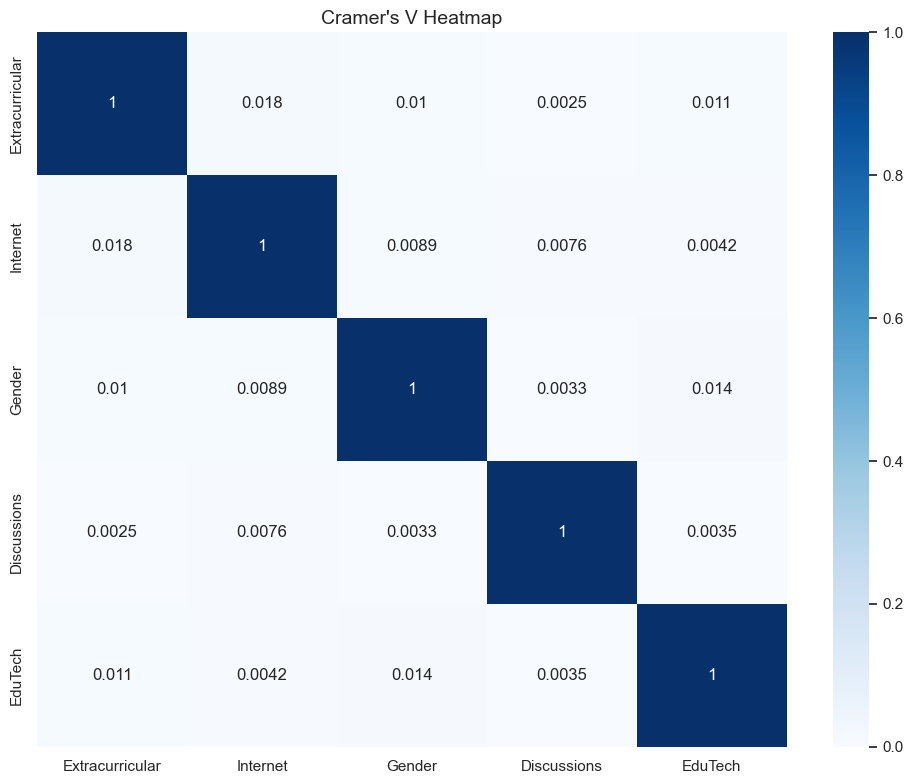

In [48]:
# 3. CRAMER'S V FOR CATEGORICAL PAIRS
cat_cols2 = categorical_cols if categorical_cols else binary_cols
if len(cat_cols2) > 1:
    from scipy.stats import chi2_contingency
    def cramers_v(x, y):
        t = pd.crosstab(x, y)
        chi2 = chi2_contingency(t)[0]
        n = t.sum().sum()
        r, k = t.shape
        return (chi2 / (n * min(r - 1, k - 1))) ** 0.5 if min(r, k) > 1 else 0
    cv = pd.DataFrame(index=cat_cols2, columns=cat_cols2, dtype=float)
    for a in cat_cols2:
        for b in cat_cols2:
            cv.loc[a, b] = 1 if a == b else cramers_v(df[a], df[b])
    plt.figure(figsize=(10, 8))
    sns.heatmap(cv, annot=True, cmap='Blues', vmin=0, vmax=1)
    plt.title("Cramer's V Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print('Not enough categorical/binary columns.')

In [49]:
# 4. POINT-BISERIAL FOR NUMERIC-BINARY PAIR
if binary_cols and numeric_cols:
    from scipy.stats import pointbiserialr
    num_col = numeric_cols[0]
    bin_col = binary_cols[0]
    r, p = pointbiserialr(df[bin_col], df[num_col])
    print(f'{num_col} vs {bin_col}: r={r:.3f}, p={p:.3g}')
else:
    print('Need at least one numeric and one binary column.')

StudyHours vs Extracurricular: r=-0.002, p=0.769


## Clean & Engineer for Clustering
Prepare the data for clustering with minimal preprocessing.

In [67]:
# 1. HANDLE MISSING VALUES
df_cluster = df.copy()
num_cols_cluster = df_cluster.select_dtypes(include='number').columns.tolist()
cat_cols_cluster = df_cluster.select_dtypes(exclude='number').columns.tolist()
for c in num_cols_cluster:
    df_cluster[c] = df_cluster[c].fillna(df_cluster[c].median())
for c in cat_cols_cluster:
    mode = df_cluster[c].mode()
    df_cluster[c] = df_cluster[c].fillna(mode.iloc[0] if not mode.empty else 'unknown')
print('Missing values imputed with median for numeric and mode for categorical columns.')

Missing values imputed with median for numeric and mode for categorical columns.


In [68]:
# 2. ENCODE CATEGORICALS
cat_cols_cluster = df_cluster.select_dtypes(exclude='number').columns.tolist()
df_encoded = pd.get_dummies(df_cluster, columns=cat_cols_cluster, drop_first=True) if cat_cols_cluster else df_cluster.copy()
print(f'Encoded categorical columns: {len(cat_cols_cluster)}')

Encoded categorical columns: 0


In [70]:
# 3. DERIVED FEATURES
df_fe = df_encoded.copy()

# Combines multiple engagement signals into one feature
df_fe['engagement_score'] = df_fe[
    ['StudyHours', 'Attendance', 'AssignmentCompletion', 'Discussions']
].mean(axis=1)

# Approximate study time per online course; clip avoids division by zero
df_fe['avg_session_time'] = df_fe['StudyHours'] / df_fe['OnlineCourses'].clip(lower=1)

print('Derived features added: engagement_score, avg_session_time')

Derived features added: engagement_score, avg_session_time


-These features were created to better capture overall student behavior by combining related signals, making clustering more meaningful by reducing noise and improving how similarity between students is measured.

-These two features were selected because they capture two complementary aspects of student behavior: overall engagement level through combined activity signals, and learning intensity per course through study time distribution, giving clearer and more meaningful clustering than raw variables alone.

In [71]:
# 4. SCALE FEATURES
from sklearn.preprocessing import StandardScaler
from pathlib import Path
scaler = StandardScaler()
df_scaled = df_fe.copy()
num_cols = df_scaled.select_dtypes(include='number').columns
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])
output_path = Path('../data/df_scaled.csv')
df_scaled.to_csv(output_path, index=False)
print(f'Saved scaled dataset to: {output_path}')
display(df_scaled.head())

Saved scaled dataset to: ..\data\df_scaled.csv


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade,engagement_score,avg_session_time
0,-0.167633,-1.411667,-0.149721,-1.209965,-1.301687,0.283687,-1.109914,-1.289686,0.435384,-0.309518,0.806547,-1.059520,-1.715729,-1.561141,-0.387549,1.383935,-1.639074,-0.353809
1,-0.167633,-1.411667,-0.149721,-1.209965,-1.301687,0.283687,-1.109914,-0.151436,1.333936,0.999258,-1.239853,1.059174,-0.245763,-1.561141,-0.387549,0.492279,-0.116250,-0.550152
2,-0.167633,-1.411667,-0.149721,-1.209965,-1.301687,0.283687,-1.109914,1.271376,-0.463169,1.490049,-1.239853,-0.512761,1.619963,0.640557,-0.387549,-1.291031,-1.283748,-0.581153
3,-0.167633,-1.411667,-0.149721,0.826470,-1.301687,0.283687,-1.109914,-1.289686,0.435384,-0.309518,0.806547,-1.059520,-1.715729,-1.561141,-0.387549,1.383935,-1.639074,-0.353809
4,-0.167633,-1.411667,-0.149721,0.826470,-1.301687,0.283687,-1.109914,-0.151436,1.333936,0.999258,-1.239853,1.059174,-0.245763,-1.561141,-0.387549,0.492279,-0.116250,-0.550152


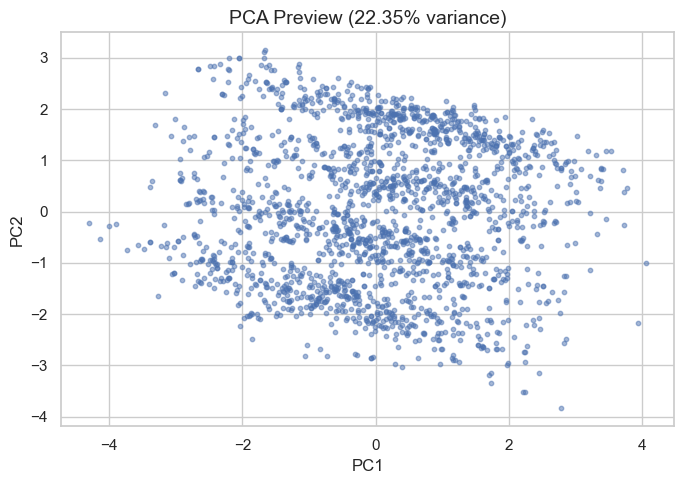

In [ ]:
# 5. PCA VISUALIZATION
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
pca_xy = pca.fit_transform(df_scaled[num_cols])
pca_df = pd.DataFrame(pca_xy, columns=['PC1', 'PC2'])
sample_pca = pca_df.sample(n=min(len(pca_df), 2000), random_state=42)
plt.figure(figsize=(7, 5))
plt.scatter(sample_pca['PC1'], sample_pca['PC2'], s=10, alpha=0.5)
plt.title(f'PCA Preview ({pca.explained_variance_ratio_.sum():.2%} variance)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

## Key Findings

In [ ]:
# 1. KEY STATS
summary_stats = pd.DataFrame({
    'min': df[numeric_cols].min(),
    'max': df[numeric_cols].max(),
    'missing_pct': (df[numeric_cols].isna().mean() * 100).round(2),
})
display(summary_stats)

,min,max,missing_pct,dominant_value
StudyHours,5,44,0.0,22
Attendance,60,100,0.0,98
Resources,0,2,0.0,1
Extracurricular,0,1,0.0,1
Motivation,0,2,0.0,1
Internet,0,1,0.0,1
Gender,0,1,0.0,1
Age,18,29,0.0,19
LearningStyle,0,3,0.0,1
OnlineCourses,0,20,0.0,5


In [56]:
# 2. STRONG CORRELATIONS
corr_abs = df[numeric_cols].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
strong_corr = upper.stack().sort_values(ascending=False).head(10)
display(strong_corr)

ExamScore             FinalGrade       0.968348
Attendance            Age              0.043953
Discussions           FinalGrade       0.039741
StressLevel           FinalGrade       0.037786
ExamScore             StressLevel      0.032206
Attendance            LearningStyle    0.031512
AssignmentCompletion  FinalGrade       0.030145
Gender                LearningStyle    0.030066
Discussions           ExamScore        0.028813
Attendance            Gender           0.027942
dtype: float64

In [57]:
# 3. USEFUL FEATURES FOR CLUSTERING
cluster_base = df_fe.select_dtypes(include='number') if 'df_fe' in globals() else df[numeric_cols]
corr_abs = cluster_base.corr().abs()
mean_corr = corr_abs.mean().sort_values()
feature_score = pd.DataFrame({
    'std': cluster_base.std().sort_values(ascending=False),
    'mean_abs_corr': mean_corr.reindex(cluster_base.columns),
})
feature_score['cluster_score'] = feature_score['std'] / (1 + feature_score['mean_abs_corr'])
display(feature_score.sort_values('cluster_score', ascending=False).head(10))

,std,mean_abs_corr,cluster_score
ExamScore,17.688113,0.122837,15.753059
AssignmentCompletion,14.632177,0.108719,13.197370
Attendance,11.472181,0.102584,10.404809
OnlineCourses,6.112801,0.100501,5.554564
avg_session_time,6.048323,0.118249,5.408742
StudyHours,5.890637,0.095452,5.377357
engagement_score,4.925236,0.160647,4.243526
Age,3.514293,0.066887,3.293970
LearningStyle,1.112941,0.069361,1.040754
FinalGrade,1.121550,0.124881,0.997039


##  summary
The dataset is clean and mostly made of numerical values, so it is ready for clustering after scaling. Exam scores, attendance, and assignment completion show the most variation, while many other features are weakly related, which is good for grouping students. The strongest relationship is between ExamScore and FinalGrade, so these two should be checked to avoid redundancy. Overall, the data includes performance, engagement, and behavior information that can help form meaningful student groups.

In [ ]:
# DOMINANT CATEGORIES
dominant_cols = binary_cols + ordinal_discrete_cols
dominant_table = pd.DataFrame({
    'dominant_value': [df[c].mode().iloc[0] for c in dominant_cols],
    'count': [df[c].value_counts().iloc[0] for c in dominant_cols],
}, index=dominant_cols)
display(dominant_table)

,dominant_value,count
Extracurricular,1,8320
Internet,1,12960
Gender,1,7729
Discussions,1,8484
EduTech,1,9929
Resources,1,7041
Motivation,1,7098
LearningStyle,1,3580
StressLevel,2,7098
FinalGrade,0,3832


## Final Feature Set Definition
Define the exact input matrix for clustering (`X_model`).

In [73]:
# 1. BUILD X_MODEL (FINAL CLUSTERING INPUT)
num_cols_model = df_scaled.select_dtypes(include='number').columns.tolist()

# Target-like / overly descriptive variables to exclude from unsupervised clustering
manual_drop = [c for c in ['FinalGrade', 'ExamScore'] if c in num_cols_model]
candidate_cols = [c for c in num_cols_model if c not in manual_drop]

# Optional de-redundancy: drop one feature from very high-correlation pairs
corr_matrix = df_scaled[candidate_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_drop = [col for col in upper.columns if any(upper[col] > 0.90)]

# Explicit feature list used by both K-Means and DBSCAN
chosen_features = [c for c in candidate_cols if c not in high_corr_drop]
X_model = df_scaled[chosen_features].copy()

print('Manual drop (target-like):', manual_drop)
print('High-correlation drop (>0.90):', high_corr_drop)
print('Chosen feature count:', len(chosen_features))
print('X_model shape:', X_model.shape)
display(pd.DataFrame({'feature': chosen_features}))

Manual drop (target-like): ['FinalGrade', 'ExamScore']
High-correlation drop (>0.90): []
Chosen feature count: 16
X_model shape: (14003, 16)


,feature
0,StudyHours
1,Attendance
2,Resources
3,Extracurricular
4,Motivation
5,Internet
6,Gender
7,Age
8,LearningStyle
9,OnlineCourses


I dropped these two columns because they represent final performance outcomes, and keeping them would make clusters group students mainly by grades instead of their underlying behavior patterns.

In [74]:
# 2. EXPORT FINAL MODELING DATASET
data_modeling = X_model.copy()
export_path = Path('../data/data_modeling.csv')
data_modeling.to_csv(export_path, index=False)
print(f'Saved modeling dataset to: {export_path}')
print('data_modeling shape:', data_modeling.shape)
display(data_modeling.head())

Saved modeling dataset to: ..\data\data_modeling.csv
data_modeling shape: (14003, 16)


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,EduTech,StressLevel,engagement_score,avg_session_time
0,-0.167633,-1.411667,-0.149721,-1.209965,-1.301687,0.283687,-1.109914,-1.289686,0.435384,-0.309518,0.806547,-1.059520,-1.561141,-0.387549,-1.639074,-0.353809
1,-0.167633,-1.411667,-0.149721,-1.209965,-1.301687,0.283687,-1.109914,-0.151436,1.333936,0.999258,-1.239853,1.059174,-1.561141,-0.387549,-0.116250,-0.550152
2,-0.167633,-1.411667,-0.149721,-1.209965,-1.301687,0.283687,-1.109914,1.271376,-0.463169,1.490049,-1.239853,-0.512761,0.640557,-0.387549,-1.283748,-0.581153
3,-0.167633,-1.411667,-0.149721,0.826470,-1.301687,0.283687,-1.109914,-1.289686,0.435384,-0.309518,0.806547,-1.059520,-1.561141,-0.387549,-1.639074,-0.353809
4,-0.167633,-1.411667,-0.149721,0.826470,-1.301687,0.283687,-1.109914,-0.151436,1.333936,0.999258,-1.239853,1.059174,-1.561141,-0.387549,-0.116250,-0.550152
